<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/9_6_1_KnearestNeighbours.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/knn_handwritten_digits.csv')

print(data.shape)
data.head()

(1797, 65)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
data.isnull().sum()

,0
pixel_0,0
pixel_1,0
pixel_2,0
pixel_3,0
pixel_4,0
...,...
pixel_60,0
pixel_61,0
pixel_62,0
pixel_63,0


In [ ]:
X = data.drop('digit', axis=1)
y = data['digit']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

print(x_train.shape)
print(x_test.shape)

(1257, 64)
(540, 64)


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
results = []

for i in [1, 2, 3, 4, 5]:

    model = KNeighborsClassifier(
        n_neighbors=i,
        metric='minkowski',
        p=2
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy_score = metrics.accuracy_score(
        y_test,
        y_pred
    )

    results.append(accuracy_score)

print(results)

[0.9740740740740741, 0.9629629629629629, 0.9722222222222222, 0.9629629629629629, 0.9703703703703703]


In [ ]:
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN [minkowski]")
print("For n_neighbor=5:")

conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy_score)

print(
    "Accuracy in Percentage:",
    int(accuracy_score * 100),
    "%"
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

KNN [minkowski]
For n_neighbor=5:

Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 52  0  0  0  0  0  0  0  0]
 [ 0  1 51  0  0  0  0  1  0  0]
 [ 0  0  0 52  0  0  0  0  2  0]
 [ 0  0  0  0 46  0  0  2  0  0]
 [ 0  0  0  0  0 54  1  0  0  2]
 [ 0  0  0  0  0  0 60  0  0  0]
 [ 0  0  0  0  2  0  0 51  0  0]
 [ 0  1  0  2  0  0  0  0 58  0]
 [ 0  0  0  0  0  1  0  1  0 55]]
Accuracy Score: 0.9703703703703703
Accuracy in Percentage: 97 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.96      1.00      0.98        52
           2       1.00      0.96      0.98        53
           3       0.96      0.96      0.96        54
           4       0.96      0.96      0.96        48
           5       0.98      0.95      0.96        57
           6       0.98      1.00      0.99        60
           7       0.93      0.96      0.94        53
           8       0.97      0.95      0.

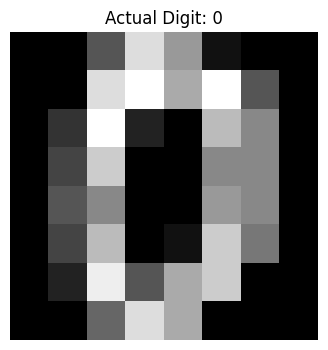

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

plt.figure(figsize=(4, 4))

plt.imshow(
    digits.images[0],
    cmap='gray'
)

plt.title(
    'Actual Digit: ' + str(digits.target[0])
)

plt.axis('off')
plt.show()

In [ ]:
results = []

for i in [1, 2, 3, 4, 5]:

    model = KNeighborsClassifier(
        n_neighbors=i,
        metric='minkowski',
        p=2
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = metrics.accuracy_score(
        y_test,
        y_pred
    )

    results.append(accuracy)

models = pd.DataFrame({
    'n_neighbors': [1, 2, 3, 4, 5],
    'Accuracy Score': results
})

models = models.sort_values(
    by='Accuracy Score',
    ascending=False
)

print(models.to_string(index=False))

 n_neighbors  Accuracy Score
           1        0.974074
           3        0.972222
           5        0.970370
           2        0.962963
           4        0.962963


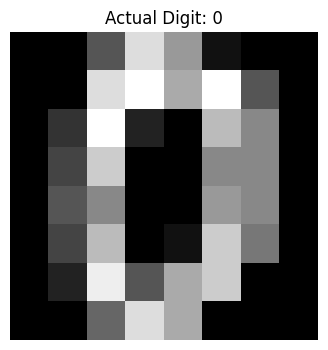

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

plt.figure(figsize=(4, 4))

plt.imshow(
    digits.images[0],
    cmap='gray'
)

plt.title(
    'Actual Digit: ' + str(digits.target[0])
)

plt.axis('off')
plt.show()

In [ ]:
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN [minkowski]")
print("For n_neighbor=5:")

conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy_score)

print(
    "Accuracy in Percentage:",
    int(accuracy_score * 100),
    "%"
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

KNN [minkowski]
For n_neighbor=5:

Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 52  0  0  0  0  0  0  0  0]
 [ 0  1 51  0  0  0  0  1  0  0]
 [ 0  0  0 52  0  0  0  0  2  0]
 [ 0  0  0  0 46  0  0  2  0  0]
 [ 0  0  0  0  0 54  1  0  0  2]
 [ 0  0  0  0  0  0 60  0  0  0]
 [ 0  0  0  0  2  0  0 51  0  0]
 [ 0  1  0  2  0  0  0  0 58  0]
 [ 0  0  0  0  0  1  0  1  0 55]]
Accuracy Score: 0.9703703703703703
Accuracy in Percentage: 97 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.96      1.00      0.98        52
           2       1.00      0.96      0.98        53
           3       0.96      0.96      0.96        54
           4       0.96      0.96      0.96        48
           5       0.98      0.95      0.96        57
           6       0.98      1.00      0.99        60
           7       0.93      0.96      0.94        53
           8       0.97      0.95      0.